In [1]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from spec.enums import MainTableColumns as Cols

In [2]:
# base_dir = '../../../sample_data/cwo/s19/analysis/'
# base_dir = '../../../sample_data/cwo/f19/analysis/'
base_dir = '../../../sample_data/codebench/2024/analysis/'

In [3]:
data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))

In [4]:
data.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,945591435.0,158242931,0.167663,1.423357,0.603589,-0.566327,1.178000,1.270447,-0.106331,1.428937,...,-0.025386,-0.100341,-0.170601,0.233839,-0.080778,-0.170601,-0.091311,-0.288039,-0.444761,1.49
1,945591435.0,188644686,-0.526130,-0.543470,-0.578249,-0.415655,-0.554165,-0.962316,0.733106,-1.113780,...,0.772179,0.876892,-0.642909,-1.020661,-0.544176,-0.642909,-0.842020,0.653578,0.308537,8.75
2,945591435.0,414686080,1.977535,1.653210,1.895838,-0.257587,1.243346,0.603141,0.397351,0.606538,...,-1.842669,-1.779635,0.567544,1.368916,0.820824,0.567544,2.165162,-1.112342,0.824709,5.66
3,945591435.0,530793764,0.986522,1.203113,1.069224,-0.145359,0.346904,0.583563,0.417594,0.581460,...,0.548531,0.344377,-0.816364,0.246179,-0.525786,-0.816364,0.331814,-0.613979,-0.077464,3.12
4,945591435.0,873175644,2.185542,2.277444,2.120679,-0.785217,0.136957,1.585580,-1.055829,1.564655,...,-0.160575,-0.199926,0.278511,0.158734,0.360290,0.278511,0.089506,-0.467878,0.052402,3.42


In [7]:
# There's just one CS course with 18 students, so I don't think it's
# worth treating as a separate prediction.
data = data[data["X-ClassID"] != 2607741091]

In [24]:
grouping_cols = ["X-ClassID", Cols.SubjectID]
grouping_cols = [col for col in grouping_cols if col in data.columns]

In [25]:
X = data.drop(columns=grouping_cols + ['Grade'])
y = data['Grade']

In [26]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: []


In [27]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                       Feature1                     Feature2  Correlation
0               ActiveTime_mean               TotalTime_mean     0.963542
1              PassiveTime_mean               TotalTime_mean     0.919006
2                TotalTime_mean              ActiveTime_mean     0.963542
3                TotalTime_mean             PassiveTime_mean     0.919006
4   ActiveTimeAfterCorrect_mean   ActiveTimeAfterCorrect_sum     0.911866
5                StartTime_mean                 EndTime_mean     0.982419
6         FirstCorrectTime_mean             EverCorrect_mean     0.930591
7         FirstCorrectTime_mean                MaxScore_mean     0.998270
8         FirstCorrectTime_mean    AtLeatMedianMaxScore_mean     0.999230
9                  EndTime_mean               StartTime_mean     0.982419
10                Attempts_mean           TotalAttempts_mean     0.979340
11                Attempts_mean    RepeatedErrorDensity_mean     0.922328
12            

<Axes: >

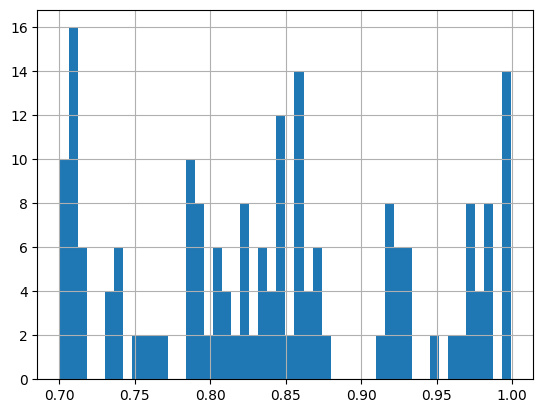

In [28]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [29]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['ActiveTime_mean', 'TotalTime_mean', 'ActiveTime_mean', 'TotalTime_mean', 'ActiveTimeAfterCorrect_sum', 'EndTime_mean', 'EverCorrect_mean', 'FirstCorrectTime_mean', 'FirstCorrectTime_mean', 'EndTime_mean', 'TotalAttempts_mean', 'Attempts_mean', 'FailedCompileCount_mean', 'FirstCorrect_mean', 'FirstCorrect_mean', 'EverCorrect_mean', 'EverCorrect_mean', 'EverCorrect_mean', 'FirstCorrectTime_mean', 'EverCorrect_mean', 'MaxScore_mean', 'FirstCorrect_mean', 'MinScore_mean', 'FirstCorrect_mean', 'MinScore_mean', 'TotalAttempts_mean', 'TotalAttempts_mean', 'Attempts_mean', 'TotalAttempts_mean', 'FailedCompileCount_mean', 'FailedCompileCount_mean', 'FailedCompileCount_mean', 'FirstCorrectTime_mean', 'EverCorrect_mean', 'MaxScore_mean', 'ActiveTime_sum', 'TotalTime_sum', 'ActiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum', 'EndTime_sum', 'MaxScore_sum', 'FirstCorrectTime_sum', 'EndTime_sum', 'TotalAttempts_sum', 'Attempts_sum', 'FailedCompil

In [33]:
X_lean.columns

Index(['PassiveTime_mean', 'ActiveTimeAfterCorrect_mean', '#Breaks_mean',
       'StartTime_mean', 'Attempted_mean', 'MeanScore_mean',
       'ErrorQuotient_mean', 'RepeatedErrorDensity_mean',
       'AtLeatMedianActiveTime_mean', 'AtLeatMedianMaxScore_mean',
       'HadEffort_mean', 'PassiveTime_sum', '#Breaks_sum', 'StartTime_sum',
       'FirstCorrect_sum', 'EverCorrect_sum', 'MeanScore_sum',
       'ErrorQuotient_sum', 'RepeatedErrorDensity_sum',
       'AtLeatMedianActiveTime_sum', 'AtLeatMedianMaxScore_sum',
       'HadEffort_sum'],
      dtype='object')

In [31]:
# Use the original data to peak at Grade
data.drop(columns=to_drop).drop(columns=grouping_cols).corr(method='spearman')

,PassiveTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,Attempted_mean,MeanScore_mean,ErrorQuotient_mean,RepeatedErrorDensity_mean,AtLeatMedianActiveTime_mean,AtLeatMedianMaxScore_mean,...,StartTime_sum,FirstCorrect_sum,EverCorrect_sum,MeanScore_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
PassiveTime_mean,1.000000,0.310601,0.737359,0.435209,-0.357034,-0.578288,-0.074051,0.482886,0.658405,-0.489106,...,0.460298,-0.232823,-0.080611,-0.535006,-0.056843,0.353384,0.656709,-0.455280,-0.238351,-0.276145
ActiveTimeAfterCorrect_mean,0.310601,1.000000,0.286532,0.080065,0.123516,-0.116728,-0.217988,0.410362,0.326950,0.102284,...,0.102096,0.247040,0.389813,-0.095659,-0.005662,0.076943,0.282390,0.139619,0.234277,0.247999
#Breaks_mean,0.737359,0.286532,1.000000,0.348863,-0.313390,-0.443022,-0.138530,0.464396,0.546446,-0.397993,...,0.404719,-0.079365,0.059979,-0.477867,-0.037882,0.239461,0.568915,-0.395588,-0.206458,-0.164199
StartTime_mean,0.435209,0.080065,0.348863,1.000000,-0.266460,-0.282374,-0.016632,0.142469,0.577771,-0.425221,...,0.895892,-0.226293,-0.204142,-0.306874,-0.136481,0.217642,0.571562,-0.424069,-0.307606,-0.287693
Attempted_mean,-0.357034,0.123516,-0.313390,-0.266460,1.000000,0.454942,-0.060508,-0.001557,-0.217487,0.750295,...,-0.242110,0.280496,0.314692,0.353331,0.046297,-0.063890,-0.233700,0.650250,0.624324,0.412335
MeanScore_mean,-0.578288,-0.116728,-0.443022,-0.282374,0.454942,1.000000,0.216491,-0.596999,-0.428863,0.677152,...,-0.286685,0.619187,0.313814,0.905453,0.255881,-0.555866,-0.457537,0.597920,0.424316,0.449985
ErrorQuotient_mean,-0.074051,-0.217988,-0.138530,-0.016632,-0.060508,0.216491,1.000000,-0.240762,-0.067656,-0.054558,...,-0.116871,0.014085,-0.125205,0.263052,0.815822,-0.040726,-0.075786,-0.005470,-0.001603,-0.085170
RepeatedErrorDensity_mean,0.482886,0.410362,0.464396,0.142469,-0.001557,-0.596999,-0.240762,1.000000,0.401074,-0.188520,...,0.159848,-0.142976,0.127048,-0.604384,-0.100083,0.681343,0.397502,-0.164690,0.007973,-0.018764
AtLeatMedianActiveTime_mean,0.658405,0.326950,0.546446,0.577771,-0.217487,-0.428863,-0.067656,0.401074,1.000000,-0.384424,...,0.566878,-0.162305,-0.007341,-0.469729,-0.051460,0.309984,0.909801,-0.351883,-0.110795,-0.198109
AtLeatMedianMaxScore_mean,-0.489106,0.102284,-0.397993,-0.425221,0.750295,0.677152,-0.054558,-0.188520,-0.384424,1.000000,...,-0.386360,0.556916,0.561807,0.564201,0.096196,-0.311671,-0.372339,0.916090,0.752024,0.690618


In [34]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.25, random_state=42)

In [35]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    # 'n_estimators': [50, 100, 200, 350, 500],
    'n_estimators': [10, 20, 50, 100, 200],
    'max_depth': [1, 5, 10, 20, 30],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': 20, 'n_estimators': 100}


In [36]:
pd.DataFrame(grid_search.cv_results_)[["mean_train_score", "mean_test_score", "std_test_score", "params"]]

,mean_train_score,mean_test_score,std_test_score,params
0,-1.174127,-1.300646,0.189215,"{'max_depth': 1, 'n_estimators': 10}"
1,-1.143226,-1.241610,0.126284,"{'max_depth': 1, 'n_estimators': 20}"
2,-1.149608,-1.238129,0.144933,"{'max_depth': 1, 'n_estimators': 50}"
3,-1.141341,-1.210550,0.160757,"{'max_depth': 1, 'n_estimators': 100}"
4,-1.139344,-1.206326,0.152920,"{'max_depth': 1, 'n_estimators': 200}"
5,-0.523992,-0.999827,0.134863,"{'max_depth': 5, 'n_estimators': 10}"
6,-0.503576,-1.019279,0.118501,"{'max_depth': 5, 'n_estimators': 20}"
7,-0.486930,-0.997777,0.136112,"{'max_depth': 5, 'n_estimators': 50}"
8,-0.490669,-0.992941,0.137866,"{'max_depth': 5, 'n_estimators': 100}"
9,-0.493129,-0.996879,0.135041,"{'max_depth': 5, 'n_estimators': 200}"


<Axes: xlabel='mean_train_score', ylabel='mean_test_score'>

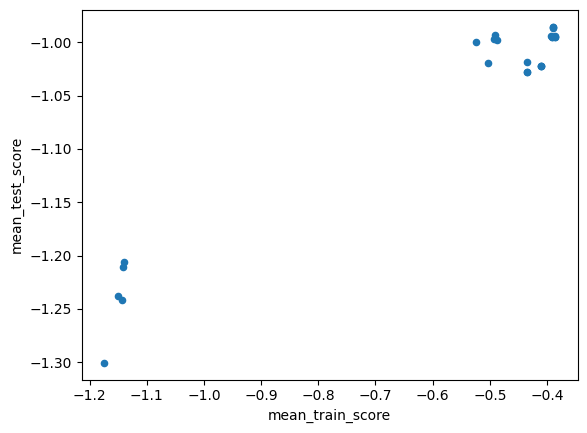

In [37]:
pd.DataFrame(grid_search.cv_results_).plot.scatter("mean_train_score", "mean_test_score")

In [38]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# Create a table of each feature and its coefficient
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_,
    'Abs_Coefficient': abs(lasso.coef_)
})
lasso_coef.sort_values(by='Abs_Coefficient', ascending=False)


,Feature,Coefficient,Abs_Coefficient
15,EverCorrect_sum,1.592801,1.592801
9,AtLeatMedianMaxScore_mean,1.087058,1.087058
19,AtLeatMedianActiveTime_sum,-0.224238,0.224238
20,AtLeatMedianMaxScore_sum,0.112332,0.112332
7,RepeatedErrorDensity_mean,0.008092,0.008092
18,RepeatedErrorDensity_sum,-0.007961,0.007961
5,MeanScore_mean,0.000000,0.000000
4,Attempted_mean,0.000000,0.000000
3,StartTime_mean,0.000000,0.000000
2,#Breaks_mean,-0.000000,0.000000


In [39]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
gb_grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='neg_mean_absolute_error')
gb_grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [60]:
pd.DataFrame(gb_grid_search.cv_results_)[["mean_test_score", "std_test_score", "params"]]

,mean_test_score,std_test_score,params
0,-14.070226,1.026319,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
1,-13.694874,1.057721,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
2,-13.323236,1.149085,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
3,-14.058691,0.918846,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
4,-13.669812,0.815984,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
5,-13.401350,0.738296,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
6,-14.270673,1.045810,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
7,-14.021896,1.048530,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
8,-14.102301,1.022204,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
9,-13.492725,1.089331,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [40]:
from sklearn.metrics import mean_absolute_error, r2_score

print(mean_absolute_error(y_test, grid_search.predict(X_test)))
print(r2_score(y_test, grid_search.predict(X_test)))

0.9992083333333338
0.7158841978953883


In [41]:
print(mean_absolute_error(y_test, lasso.predict(X_test)))
print(r2_score(y_test, lasso.predict(X_test)))

0.9994976307164295
0.7522436060195699


In [42]:
print(mean_absolute_error(y_test, gb_grid_search.predict(X_test)))
print(r2_score(y_test, gb_grid_search.predict(X_test)))

0.9719276365263028
0.7502706946180484


In [43]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)

print(mean_absolute_error(y_test, dummy_regressor.predict(X_test)))
print(r2_score(y_test, dummy_regressor.predict(X_test)))

2.1550605791962174
-0.009603068064369946


In [60]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train[['EverCorrect_sum']], y_train)

ever_correct_baseline = linear_reg.predict(X_test[['EverCorrect_sum']])
print(mean_absolute_error(y_test, ever_correct_baseline))
print(r2_score(y_test, ever_correct_baseline))

1.0116365395606997
0.7195932799940483


<Axes: >

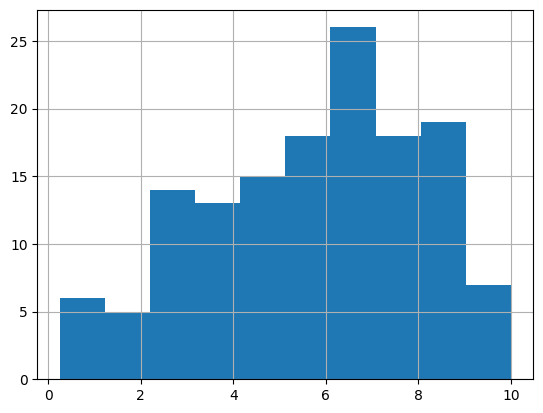

In [44]:
y_train.hist()

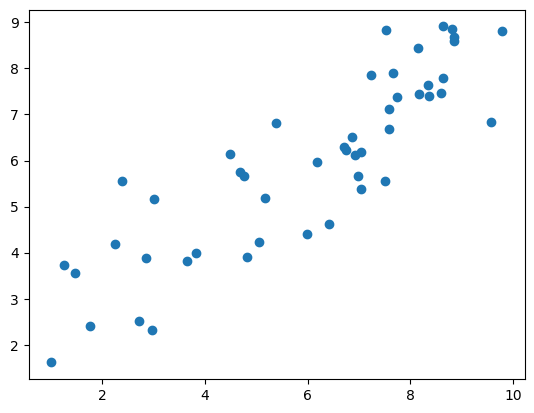

In [56]:
plt.scatter(y_test, gb_grid_search.predict(X_test))

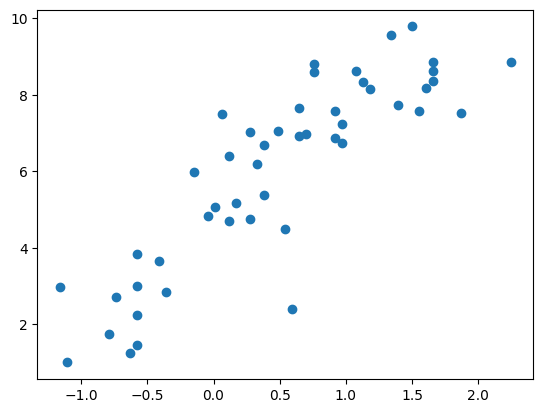

In [54]:
plt.scatter(X_test['EverCorrect_sum'], y_test)